<font size=6><b> lec07_1.분석모형 : 분류

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [ ]:
def myscore(df , sk=None, hist=None, pr_curv=None, roc_curv=None) :
    y = df['target']
    X = df.drop('target', axis=1)
    X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2,  random_state=4567, stratify=y)
    
    model_list = [ LogisticRegression(), DecisionTreeClassifier(random_state=4567), RandomForestClassifier(random_state=4567)
               , XGBClassifier(random_state=4567) , LGBMClassifier(random_state=4567, verbosity=-1)
             ]
    for model in model_list:
        print(f" {model.__class__.__name__} --------------------" )  
        model.fit(X80, y80)
        pred = model.predict(X20)
        proba = model.predict_proba(X20)
        
        acc       = accuracy_score(y20        , pred)
        f1        = f1_score(y20              , pred)
        precision = precision_score(y20       , pred) 
        recall    = recall_score(y20          , pred) 
        roc_auc   = roc_auc_score(y20         , proba[:,1])     #------------------
        report    = classification_report(y20 , pred)
        cm        = confusion_matrix(y20      , pred)
        
        print(f"acc:{acc:.4f}\t f1:{f1:.4f}\t precision:{precision:.4f}\t recall:{recall:.4f}\t roc_auc:{roc_auc:.4f}")
        #print(report)
        print(cm)
        print()  

        if(sk) :
            skdf = pd.DataFrame()
            col_list = ['pgcnt', 'glucose', 'bpress', 'skin', 'insulin', 'bmi', 'dpf', 'age']
            skdf['col']  = col_list
            skdf['skew'] = df[col_list].skew().values
            skdf['kurt'] = df[col_list].kurt().values
            print(skdf)

        if(hist) :     
            cols = ['insulin', 'bpress', 'dpf', 'bmi']
            #dfcp[cols].hist( figsize=(12,3), layout=(1,4), bins=20 )
            fig, axes = plt.subplots(1, 4, figsize=(16, 3))
            for ax, col in zip(axes, cols):
                ax.hist(df[col], bins=30)
                ax.set_title(f"{col} 왜도{df[col].skew():.2f}  첨도{df[col].kurtosis():.2f}  ")
            plt.tight_layout()
            plt.show()

        if(pr_curv) :
            p, r, th = precision_recall_curve(y20 , proba[:, 1])   #------------------
            plt.figure(figsize=(6,2))
            plt.plot   (th,    p[:len(th)] , label="precision")
            plt.plot   (th,    r[:len(th)] , label="recall")
            plt.scatter(0.55,  0.8364      , label=f"근사치 f1_score {f1_score(y20, pred):.4f}")   
            plt.plot([0,1], [0,1] , linestyle="--")
            plt.legend()
            plt.title("precison_recall_curve 차트")
            plt.show()

        if(roc_curv) :       
            fpr, tpr, th = roc_curve(y20 , proba[:, 1])             #------------------
            auc = roc_auc_score(y20, proba[:,1])
            plt.figure(figsize=(6,2))
            plt.plot   (fpr,    tpr , label=f"roc_auc_score : {auc:.4f}")            
            plt.scatter(	0.11 ,	0.886792)
            plt.plot([0,1], [0,1] , linestyle="--")
            plt.legend()
            plt.title("roc_curve 차트")
            plt.show()

In [ ]:
def myscore2(dfcp):
    
    y = dfcp['target']
    X = dfcp.drop(['target'], axis=1)
    X.shape, y.shape
    
    model_list = [LogisticRegression(), DecisionTreeClassifier(random_state=234), RandomForestClassifier(random_state=234), 
                  XGBClassifier(random_state=234), LGBMClassifier(verbosity=-1, random_state=234)]
    X80, X20, y80, y20 = train_test_split(X, y, test_size = 0.2, random_state=4567, stratify=y)
    
    scaler_list = [ None, StandardScaler(), MinMaxScaler(), RobustScaler()]
    model_list  = [ LogisticRegression(), DecisionTreeClassifier(random_state=4567), RandomForestClassifier(random_state=4567)
                   , XGBClassifier(random_state=4567) , LGBMClassifier(random_state=4567, verbosity=-1)
                  ]
    for scaler in scaler_list:
        print( scaler, "--------------")
        for model in model_list:
            
            pipeline = Pipeline([
                ('scaler', scaler),
                ('model' , model)])
            pipeline.fit(X80, y80)
            pred = pipeline.predict(X20)
            f1  = f1_score(y20, pred)
            print(f"{f1:.4f}\t {model.__class__.__name__}")
        print(scaler, "log transform --------------")
        for model in model_list:
            
            pipeline = Pipeline([
                ('scaler', scaler),
                ('model' , model)])
    
            X80cp=X80.copy()
            X20cp=X20.copy()
            col_list = ['pgcnt', 'glucose', 'bpress', 'skin', 'insulin', 'bmi', 'dpf', 'age']
            X80cp[col_list] = np.log1p(X80cp[col_list])
            X20cp[col_list] = np.log1p(X20cp[col_list])
            pipeline.fit(X80cp, y80)
            pred = pipeline.predict(X20cp)
            f1  = f1_score(y20, pred)
            print(f"{f1:.4f}\t {model.__class__.__name__}")

In [ ]:
# #  Kfold 적용한 함수
# def myscore3(dfcp):
    
#     y = dfcp['target']
#     X = dfcp.drop(['target'], axis=1)
#     X.shape, y.shape
    
#     model_list = [LogisticRegression(), DecisionTreeClassifier(random_state=234), RandomForestClassifier(random_state=234), 
#                   XGBClassifier(random_state=234), LGBMClassifier(verbosity=-1, random_state=234)]
#     X80, X20, y80, y20 = train_test_split(X, y, test_size = 0.2, random_state=4567, stratify=y)
    
#     scaler_list = [ None, StandardScaler(), MinMaxScaler(), RobustScaler()]
#     model_list  = [ LogisticRegression(), DecisionTreeClassifier(random_state=4567), RandomForestClassifier(random_state=4567)
#                    , XGBClassifier(random_state=4567) , LGBMClassifier(random_state=4567, verbosity=-1)
#                   ]
#     for scaler in scaler_list:
#         print( scaler, "--------------")
#         for model in model_list:
            
#             pipeline = Pipeline([
#                 ('scaler', scaler),
#                 ('model' , model)])
#             pipeline.fit(X80, y80)
#             pred = pipeline.predict(X20)
#             f1  = f1_score(y20, pred)
#             print(f"{f1:.4f}\t {model.__class__.__name__}")
#         print(scaler, "log transform --------------")
#         for model in model_list:
            
#             pipeline = Pipeline([
#                 ('scaler', scaler),
#                 ('model' , model)])
    
#             X80cp=X80.copy()
#             X20cp=X20.copy()
#             col_list = ['pgcnt', 'glucose', 'bpress', 'skin', 'insulin', 'bmi', 'dpf', 'age']
#             X80cp[col_list] = np.log1p(X80cp[col_list])
#             X20cp[col_list] = np.log1p(X20cp[col_list])
#             pipeline.fit(X80cp, y80)
#             pred = pipeline.predict(X20cp)
#             f1  = f1_score(y20, pred)
#             print(f"{f1:.4f}\t {model.__class__.__name__}")

In [ ]:
#  Kfold 적용한 함수
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer


def clip_outliers(X):
    X_cp = X.copy()
    # 예: insulin은 0~400, bmi는 10~50 사이로 제한 (도메인 지식 기반)
    if 'insulin' in X_cp.columns:
        X_cp['insulin'] = np.clip(X_cp['insulin'], 0, 400)
    if 'bmi' in X_cp.columns:
        X_cp['bmi'] = np.clip(X_cp['bmi'], 10, 50)
    return X_cp

# 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
def log_transform_cols(X):
    X_cp = X.copy()
    col_list = ['pgcnt', 'glucose', 'bpress', 'skin', 'insulin', 'bmi', 'dpf', 'age']
    # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
    target_cols = [c for c in col_list if c in X_cp.columns]
    X_cp[target_cols] = np.log1p(X_cp[target_cols])
    return X_cp


# [최상위 레벨] 모델 파이프라인 생성 함수 (필요시 호출)
def get_pipeline():
    # globals()나 locals()를 통해 함수 존재 여부 확인
    log_scale = globals().get('log_transform_cols', None)
    outliers = globals().get('clip_outliers', None)
    
    return Pipeline([
        # 함수가 없으면 'passthrough'를 넣어 해당 단계를 건너뛰게 함
        ('clipper', FunctionTransformer(outliers) if outliers else 'passthrough'), # 이상치 제어
        ('log', FunctionTransformer(log_scale) if log_scale else 'passthrough'),
        ('scaler', StandardScaler()),
        ('model', LGBMClassifier(random_state=4567, verbosity=-1))
    ])

def prepare_data(dfcp, target_col='target'):
    y = dfcp[target_col]
    X = dfcp.drop([target_col], axis=1)
    
    # Stratified split으로 클래스 불균형 방지
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=4567, stratify=y
    )
    return X_train_full, X_test, y_train_full, y_test

def train_with_cv(X_train_full, y_train_full, n_splits=5):
    # 타겟 비율을 유지하며 폴드 생성
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=4875)
    f1_list = []
    
    print(f"--- {n_splits}-Fold Cross-Validation Starting ---")
    
    for i, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        # 파이프라인 생성 및 학습
        pipeline = get_pipeline()
        pipeline.fit(X_tr, y_tr)
        
        # 검증 데이터 평가
        pred = pipeline.predict(X_val)
        f1 = f1_score(y_val, pred)
        f1_list.append(f1)
        print(f"Fold {i}: Validation F1 = {f1:.4f}")
        
    avg_f1 = np.mean(f1_list)
    print(f"KFold Average F1: {avg_f1:.4f}\n")
    
    # 교차 검증 후, 80% 전체 데이터로 재학습한 최종 파이프라인 반환
    final_pipeline = get_pipeline()
    final_pipeline.fit(X_train_full, y_train_full)
    
    return final_pipeline, avg_f1

def evaluate_on_test(pipeline, X_test, y_test):
    print("--- Final Evaluation on Test Set ---")
    y_pred = pipeline.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)
    
    print(f"Final Test F1-Score: {test_f1:.4f}")
    
    # 혼동 행렬 등 추가 지표를 여기서 확인할 수 있음
    return test_f1
    

    
    

In [ ]:
# # 1. 데이터 준비
# X80, X_test, y80, y_test = prepare_data(dfcp)

# # 2. 훈련 및 교차 검증 (시뮬레이션 성격)
# trained_pipeline, cv_score = train_with_cv(X80, y80)

# # 3. 최종 테스트 (실제 성능 성격)
# final_score = evaluate_on_test(trained_pipeline, X_test, y_test)

In [ ]:

############# 제미나이가 준 코드 확인, 검증, 실험 XXXXXXXXXXXXXXXXXXXXXXXXXX
# from sklearn.model_selection import KFold
# from sklearn.preprocessing import FunctionTransformer

# # 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
# def log_transform_cols(X):
#     X_cp = X.copy()
#     col_list = ['pgcnt', 'glucose', 'bpress', 'skin', 'insulin', 'bmi', 'dpf', 'age']
#     # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
#     target_cols = [c for c in col_list if c in X_cp.columns]
#     X_cp[target_cols] = np.log1p(X_cp[target_cols])
#     return X_cp

# # [최상위 레벨] 모델 파이프라인 생성 함수 (필요시 호출)
# def get_pipeline():
#     return Pipeline([
#         ('log', FunctionTransformer(log_transform_cols)),
#         ('scaler', StandardScaler()),
#         ('model', LGBMClassifier(random_state=4567, verbosity=-1))
#     ])


# # 1. 최적의 전략(파라미터/전처리)을 찾기 위한 함수
# def validate_strategy(X_train_all, y_train_all, params=None):
#     kf = KFold(n_splits=5, shuffle=True, random_state=4875)
#     f1_list = []
    
#     for train_idx, val_idx in kf.split(X_train_all):
#         X_train, X_val = X_train_all.iloc[train_idx], X_train_all.iloc[val_idx]
#         y_train, y_val = y_train_all.iloc[train_idx], y_train_all.iloc[val_idx]
        
#         # 설정된 파라미터로 파이프라인 생성
#         pipeline = get_pipeline(params) 
#         pipeline.fit(X_train, y_train)
        
#         pred = pipeline.predict(X_val)
#         f1_list.append(f1_score(y_val, pred))
    
#     avg_f1 = np.mean(f1_list)
#     std_f1 = np.std(f1_list)
#     print(f"[CV Result] Avg F1: {avg_f1:.4f} (+/- {std_f1:.4f})")
#     return avg_f1

# # 2. 결정된 전략으로 최종 모델을 확정하는 함수
# def finalize_and_test(X_train_all, y_train_all, X_test, y_test, params=None):
#     print("\n" + "="*30)
#     print("Final Model Training & Testing")
#     print("="*30)
    
#     final_pipeline = get_pipeline(params)
#     final_pipeline.fit(X_train_all, y_train_all)
    
#     final_pred = final_pipeline.predict(X_test)
#     final_f1 = f1_score(y_test, final_pred)
    
#     print(f"Final Test F1-score: {final_f1:.4f}")
#     return final_pipeline

# Glass Data Load

* ref : https://archive.ics.uci.edu/ml/datasets/glass+identification


Attribute Information:
<pre>
1. Id number: 1 to 214
2. RI: refractive index
3. Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
4. Mg: Magnesium
5. Al: Aluminum
6. Si: Silicon
7. K: Potassium
8. Ca: Calcium
9. Ba: Barium
10. Fe: Iron
11. Type of glass: (class attribute)
-- 1 building_windows_float_processed
-- 2 building_windows_non_float_processed
-- 3 vehicle_windows_float_processed
-- 4 vehicle_windows_non_float_processed (none in this database)
-- 5 containers
-- 6 tableware
-- 7 headlamps



In [2]:
glass = pd.read_csv("./data/lec04_glass.csv")

## [Quiz] 데이터프레임 구조 확인

In [3]:
glass.head()

,ri,na,mg,al,si,k,ca,ba,fe,glass_type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## [Quiz] target 피쳐 확인
* glass_type별 종류, 갯수 확인
* glass_type별 종류, 갯수 확인 --> bar 차트 출력

In [4]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ri          214 non-null    float64
 1   na          214 non-null    float64
 2   mg          214 non-null    float64
 3   al          214 non-null    float64
 4   si          214 non-null    float64
 5   k           184 non-null    float64
 6   ca          214 non-null    float64
 7   ba          214 non-null    float64
 8   fe          213 non-null    float64
 9   glass_type  214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
glass.value_counts('glass_type')

glass_type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

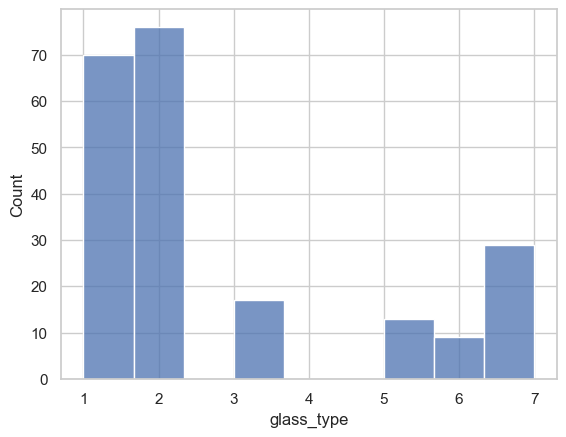

In [6]:
sns.set_theme(style='whitegrid')
ax = sns.histplot(x=glass['glass_type']) ## 수직 히스토그램

## [Quiz] 컬럼 유니크 확인
* 각 컬럼별 유니크값 개수, 해당 유니크값[:10] 출력
* 연속형, 범주형 피쳐 판단 목적

In [7]:
col_list = list(glass.columns)
col_list

['ri', 'na', 'mg', 'al', 'si', 'k', 'ca', 'ba', 'fe', 'glass_type']

In [8]:
for col in col_list:
    print(col, '::',glass[col].unique())

ri :: [1.52101 1.51761 1.51618 1.51766 1.51742 1.51596 1.51743 1.51756 1.51918
 1.51755 1.51571 1.51763 1.51589 1.51748 1.51784 1.52196 1.51911 1.51735
 1.5175  1.51966 1.51736 1.51751 1.5172  1.51764 1.51793 1.51721 1.51768
 1.51747 1.51775 1.51753 1.51783 1.51567 1.51909 1.51797 1.52213 1.51779
 1.5221  1.51786 1.519   1.51869 1.52667 1.52223 1.51898 1.5232  1.51926
 1.51808 1.51837 1.51778 1.51769 1.51215 1.51824 1.51754 1.51905 1.51977
 1.52172 1.52227 1.52099 1.52152 1.523   1.51574 1.51848 1.51593 1.51631
 1.5159  1.51645 1.51627 1.51613 1.51592 1.51646 1.51594 1.51409 1.51625
 1.51569 1.5164  1.51841 1.51605 1.51588 1.51629 1.5186  1.51689 1.51811
 1.51655 1.5173  1.5182  1.52725 1.5241  1.52475 1.53125 1.53393 1.52222
 1.51818 1.52664 1.52739 1.52777 1.51892 1.51847 1.51846 1.51829 1.51708
 1.51673 1.51652 1.51844 1.51663 1.51687 1.51707 1.52177 1.51872 1.51667
 1.52081 1.52068 1.5202  1.52614 1.51813 1.518   1.51789 1.51806 1.51711
 1.51674 1.5169  1.51851 1.51662 1.51709 1.51

# EDA & Feature Engineering

## [Quiz] 결측처리
* 피쳐 k  : 결측 '0'으로 채우기
* 피쳐 fe : 결측 '평균값'으로 채우기, 평균값은 반올림해 소수점2자리까지만 사용
* 반올림 : round(), 올림 : math.ceil(), 내림:math.floor(), 소수점 버림:math.trunc()

### 피쳐 k : 결측 '0'으로 채우기

In [9]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ri          214 non-null    float64
 1   na          214 non-null    float64
 2   mg          214 non-null    float64
 3   al          214 non-null    float64
 4   si          214 non-null    float64
 5   k           184 non-null    float64
 6   ca          214 non-null    float64
 7   ba          214 non-null    float64
 8   fe          213 non-null    float64
 9   glass_type  214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [10]:
glass[glass['k'].isnull()]

,ri,na,mg,al,si,k,ca,ba,fe,glass_type
63,1.52227,14.17,3.81,0.78,71.35,NaN,9.69,0.00,0.00,1
109,1.51818,13.72,0.00,0.56,74.45,NaN,10.99,0.00,0.00,2
110,1.52664,11.23,0.00,0.77,73.21,NaN,14.68,0.00,0.00,2
111,1.52739,11.02,0.00,0.75,73.08,NaN,14.96,0.00,0.00,2
151,1.52127,14.32,3.90,0.83,71.50,NaN,9.49,0.00,0.00,3
176,1.51905,14.00,2.39,1.56,72.37,NaN,9.57,0.00,0.00,6
177,1.51937,13.79,2.41,1.19,72.76,NaN,9.77,0.00,0.00,6
178,1.51829,14.46,2.24,1.62,72.38,NaN,9.26,0.00,0.00,6
179,1.51852,14.09,2.19,1.66,72.67,NaN,9.32,0.00,0.00,6
180,1.51299,14.40,1.74,1.54,74.55,NaN,7.59,0.00,0.00,6


In [11]:
tmp_idx = glass[glass['k'].isnull()].index
tmp_idx

Index([ 63, 109, 110, 111, 151, 176, 177, 178, 179, 180, 181, 182, 183, 184,
       190, 191, 193, 194, 197, 200, 202, 203, 204, 205, 206, 208, 210, 211,
       212, 213],
      dtype='int64')

In [12]:
# df[col_list] = df[col_list].fillna(
#     df.groupby(['target', 'age2'])[col_list].transform('mean') )

glass['k'] = glass['k'].fillna(round(glass['k'].mean(), 2))
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ri          214 non-null    float64
 1   na          214 non-null    float64
 2   mg          214 non-null    float64
 3   al          214 non-null    float64
 4   si          214 non-null    float64
 5   k           214 non-null    float64
 6   ca          214 non-null    float64
 7   ba          214 non-null    float64
 8   fe          213 non-null    float64
 9   glass_type  214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [13]:
glass.loc[tmp_idx,:]

,ri,na,mg,al,si,k,ca,ba,fe,glass_type
63,1.52227,14.17,3.81,0.78,71.35,0.58,9.69,0.00,0.00,1
109,1.51818,13.72,0.00,0.56,74.45,0.58,10.99,0.00,0.00,2
110,1.52664,11.23,0.00,0.77,73.21,0.58,14.68,0.00,0.00,2
111,1.52739,11.02,0.00,0.75,73.08,0.58,14.96,0.00,0.00,2
151,1.52127,14.32,3.90,0.83,71.50,0.58,9.49,0.00,0.00,3
176,1.51905,14.00,2.39,1.56,72.37,0.58,9.57,0.00,0.00,6
177,1.51937,13.79,2.41,1.19,72.76,0.58,9.77,0.00,0.00,6
178,1.51829,14.46,2.24,1.62,72.38,0.58,9.26,0.00,0.00,6
179,1.51852,14.09,2.19,1.66,72.67,0.58,9.32,0.00,0.00,6
180,1.51299,14.40,1.74,1.54,74.55,0.58,7.59,0.00,0.00,6


<Axes: xlabel='k', ylabel='Count'>

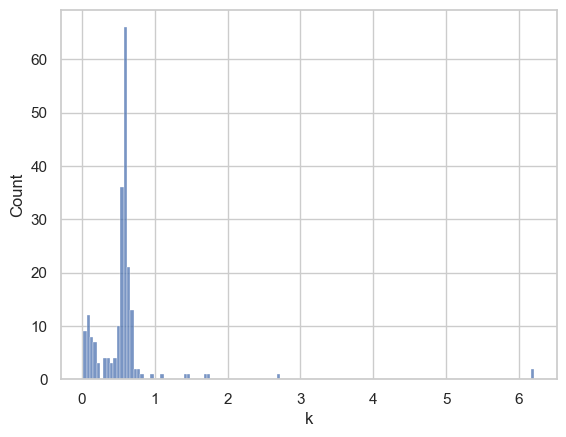

In [14]:
sns.histplot(x=glass['k']) ## 수직 히스토그램

### 피쳐 fe : 결측 glass_type별 '평균값'으로 채우기, 평균값은 반올림해 소수점2자리까지만 사용

In [15]:
glass[glass['fe'].isnull()]

,ri,na,mg,al,si,k,ca,ba,fe,glass_type
195,1.51545,14.14,0.0,2.68,73.39,0.08,9.07,0.61,NaN,7


In [16]:
glass.groupby('glass_type').agg({'fe':'mean'})

,fe
glass_type,
1,0.057000
2,0.079737
3,0.057059
5,0.060769
6,0.000000
7,0.012143


In [17]:
glass['fe'] = glass['fe'].fillna(round(
    glass.groupby(['glass_type'])['fe'].transform('mean'),2))

In [18]:
glass[glass['fe'].isnull()]

,ri,na,mg,al,si,k,ca,ba,fe,glass_type


In [19]:
glass.loc[195,:]

ri             1.51545
na            14.14000
mg             0.00000
al             2.68000
si            73.39000
k              0.08000
ca             9.07000
ba             0.61000
fe             0.01000
glass_type     7.00000
Name: 195, dtype: float64

<Axes: xlabel='fe', ylabel='Count'>

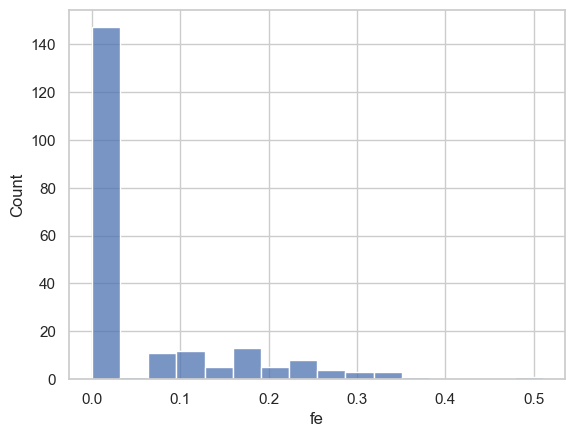

In [20]:
sns.histplot(x=glass['fe']) ## 수직 히스토그램

## 1차: 우선 점수 확인
accuracy_score()
f1_score()
roc_auc()
confusion_matrix()

In [21]:
from sklearn.ensemble import  RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score , precision_score , recall_score, precision_recall_curve, 
                            roc_curve, roc_auc_score, classification_report, confusion_matrix)

In [22]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ri          214 non-null    float64
 1   na          214 non-null    float64
 2   mg          214 non-null    float64
 3   al          214 non-null    float64
 4   si          214 non-null    float64
 5   k           214 non-null    float64
 6   ca          214 non-null    float64
 7   ba          214 non-null    float64
 8   fe          214 non-null    float64
 9   glass_type  214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [23]:
X = glass.drop('glass_type', axis=1)
y = glass['glass_type']
X.shape, y.shape

((214, 9), (214,))

In [24]:
X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, stratify=y, random_state=253)
X80.shape, X20.shape, y80.shape, y20.shape

((171, 9), (43, 9), (171,), (43,))

In [25]:
model = RandomForestClassifier(random_state=253)
model.fit(X80, y80)
pred = model.predict(X20)


In [26]:
acc_score = accuracy_score(y20, pred)
f1 = f1_score(y20, pred, average='macro')
# Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

labels = y.unique()
cm = confusion_matrix(y20, pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(acc_score, f1, '\n' ,cm_df)


0.7441860465116279 0.6555555555555556 
     1   2  3  5  6  7
1  12   1  1  0  0  0
2   3  11  0  1  0  0
3   1   1  1  0  0  0
5   0   2  0  1  0  0
6   0   0  0  1  1  0
7   0   0  0  0  0  6


In [27]:
confusion_matrix?

Signature:
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
)
Docstring:
Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    If

In [28]:
cr = classification_report(y20, pred)
print(cr)

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.73      0.73      0.73        15
           3       0.50      0.33      0.40         3
           5       0.33      0.33      0.33         3
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         6

    accuracy                           0.74        43
   macro avg       0.72      0.63      0.66        43
weighted avg       0.74      0.74      0.74        43



## [Quiz] 신규(파생) 피쳐 만들기
* 'household' 피쳐 추가
* Window 용 glass type의 경우 0의 값, 그 외(Household용)  glass type의 경우 1의 값  

<pre>
11. Type of glass: (class attribute)
-- 1 building_windows_float_processed
-- 2 building_windows_non_float_processed
-- 3 vehicle_windows_float_processed
-- 4 vehicle_windows_non_float_processed (none in this database)
-- 5 containers
-- 6 tableware
-- 7 headlamps

In [29]:
# glass['household'] = 0
# glass.loc[(glass['glass_type']==3)|
#     (glass['glass_type']==4)|
#     (glass['glass_type']==5)|
#     (glass['glass_type']==6)|
#     (glass['glass_type']==7),'house'] = 1

In [30]:
# conditions = [
#     glass['glass_type'].isin([3, 4, 5, 6, 7]), # 가정용
#     glass['glass_type'].isin([1, 2]),           # 건축용
# ]
# choices = [1, 2]

# glass['glass_category'] = np.select(conditions, choices, default=9)

In [31]:
glasscp = glass.copy()

In [32]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    glass['glass_type'].isin([5, 6, 7])
]

# 2. 결과 정의
choices = [1]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
glass['household'] = np.select(conditions, choices, default=0)

In [33]:
glass['household'].value_counts()

household
0    163
1     51
Name: count, dtype: int64

In [34]:
glass.value_counts(['household', 'glass_type']).sort_index()

household  glass_type
0          1             70
           2             76
           3             17
1          5             13
           6              9
           7             29
Name: count, dtype: int64

## [Quiz] EDA
* 주요 피쳐를 선별해 EDA 수행

<Figure size 1000x500 with 0 Axes>

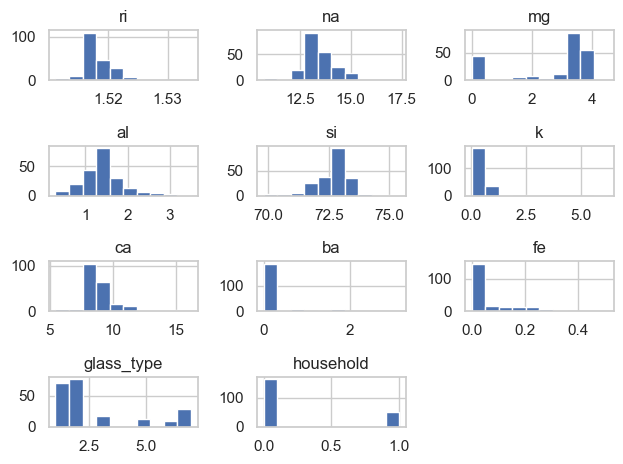

In [35]:
plt.figure(figsize=(10,5))
glass.hist()
plt.tight_layout()
plt.show()

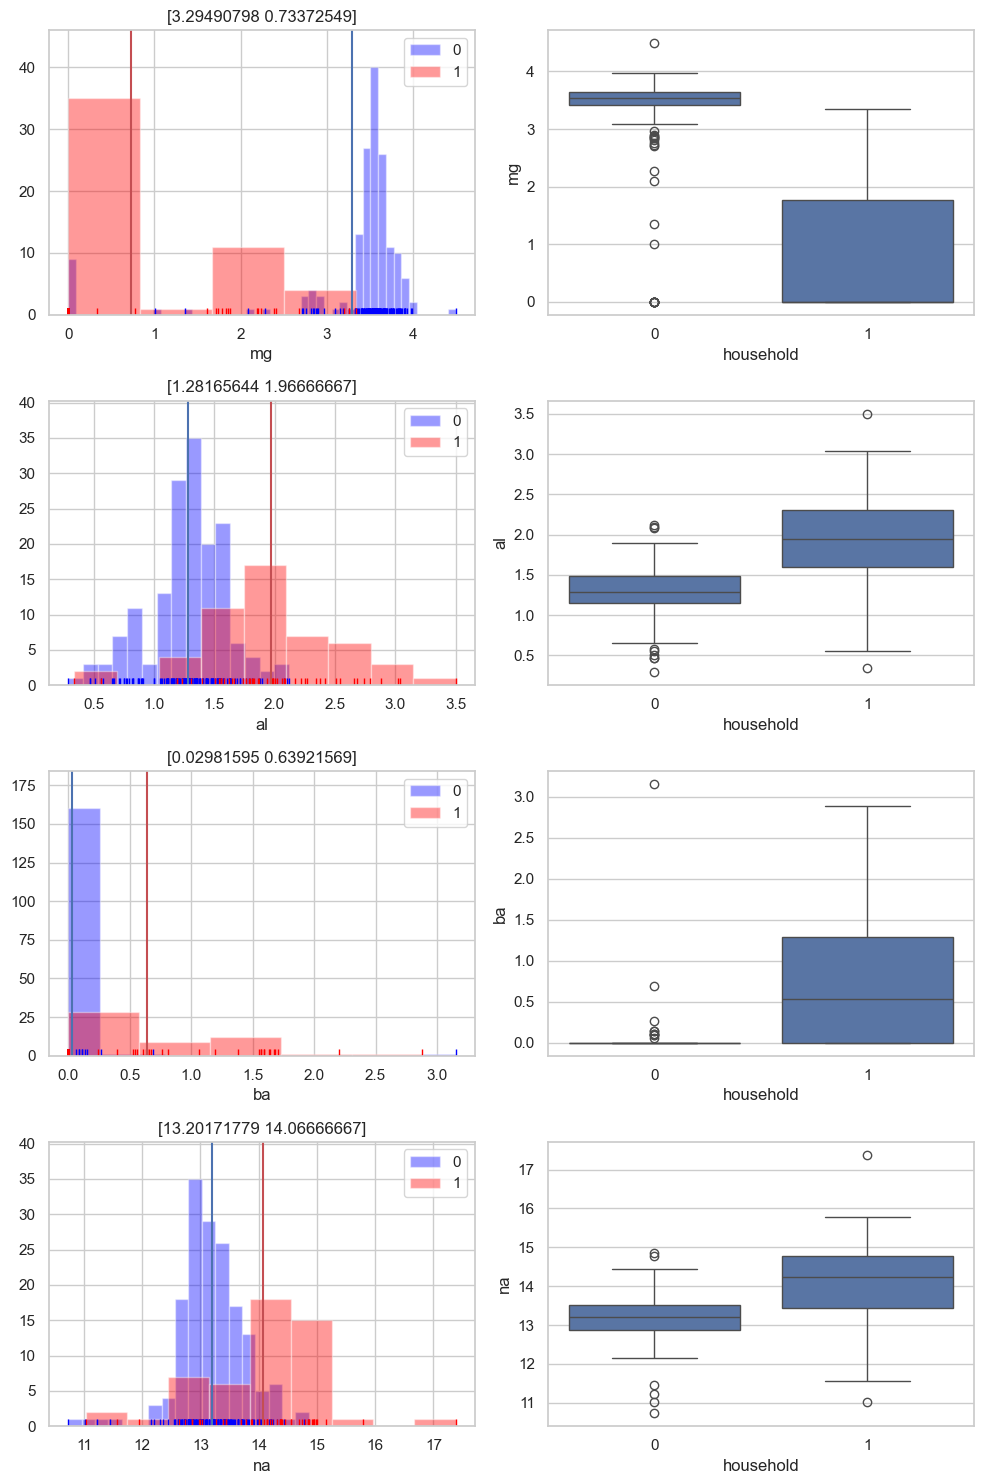

In [36]:
cols = ['mg','al', 'ba', 'na']
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(10, 15))

for i in range(len(cols)):
    col = cols[i]
    sns.distplot(glass[glass['household']==0][col]   , kde=False, rug=True, color="blue", fit_kws={"color":"#E48E58"},label="0"  ,ax=axes[i][0])
    sns.distplot(glass[glass['household']==1][col]   , kde=False, rug=True, color="red", fit_kws={"color":"#3333FF"},label="1"  ,ax=axes[i][0])
    axes[i][0].axvline(glass.groupby('household')[col].mean().values[0], color='b')
    axes[i][0].axvline(glass.groupby('household')[col].mean().values[1], color='r')
    axes[i][0].set_title(f"{glass.groupby('household')[col].mean().values}")

    axes[i][0].legend()
    sns.boxplot(x="household",     y=col, data=glass,  ax=axes[i][1])
plt.tight_layout()
plt.show()
plt.close()

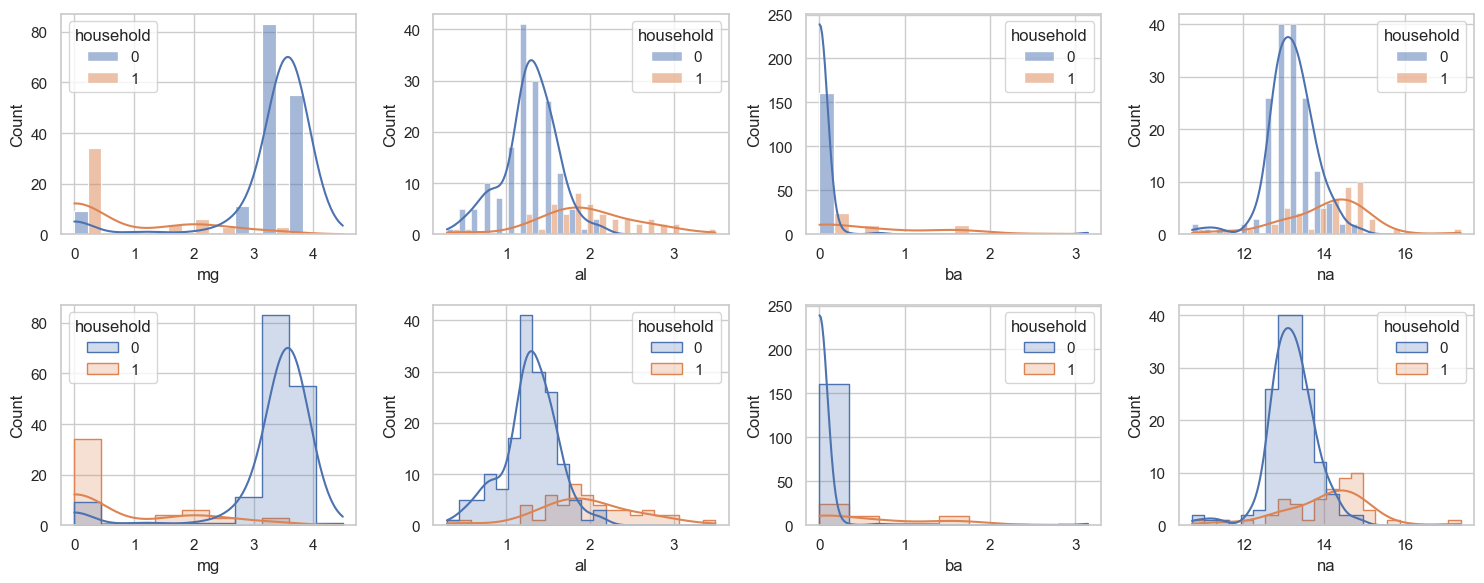

In [37]:
# 분석할 컬럼 리스트 (벡터화된 사고방식의 출발)
features = ['mg','al', 'ba', 'na']

# 1. 도화지(Figure)와 칸(Axes)을 미리 준비
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 6))
axes = axes.flatten() # 2D 배열을 1D로 펴서 for문 돌리기 쉽게 만듦

# 2. for문을 이용한 순차적 렌더링
for i, col in enumerate(features):
    sns.histplot(x=glass[col], ax=axes[i], data=glass, kde=True, hue='household', element="bars", multiple='dodge')
    sns.histplot(x=glass[col], ax=axes[i+4], data=glass, kde=True, hue='household', element="step", multiple='layer')

# 남는 빈 칸 삭제
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## [Quiz] log변환, 스케일링 


# 모델 학습 및 평가

## [Quiz] train_test 분리
* test 데이터 크기는 전체 데이터의 20% 사용

In [38]:
from sklearn.model_selection import train_test_split

## [Quiz] LogisticRegression 모델을 사용해 f1 점수 출력
* 분류모델 : from sklearn.linear_model import LogisticRegression
* 모델은 기본 파라미터 사용

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

lr_model = LogisticRegression(penalty='l2', C=1.0)


# 모델 평가 및 검증
* confusion_metrics 사용해 가장 많은 오분류를 내고 있는 glass_type 확인

In [ ]:
StrafifiedKFold()

In [40]:
glass['glass_type'].unique()

array([1, 2, 3, 5, 6, 7])

In [42]:
import xgboost
print(xgboost.__version__)

3.1.3
